In [35]:
import json
import heapq
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe
import random
import time 

### Assignment 1 ###

#### Part 1 Finding a Shortest Path with An Energy Budget ####

First we define some useful helper functions

In [2]:
def read_json(filename):
    with open(filename, 'r') as f:
        data = json.load(f)
    return data #This will return a dictionary

def get_neighbours(G, V):
    return G[V]

def get_dist(dict, edge_key):
    return dict[edge_key]

def get_cost(dict, edge_key):
    return dict[edge_key]


In [3]:
graph = read_json('G.json')
distances = read_json('Dist.json')
costs = read_json('Cost.json')
coordinates = read_json('Coord.json')

### Task 1
Here, we will solve a relaxed version of the NYC instance where we do not have the energy
constraint. 

From the lectures, the most suitable algortihm for this task is the **Uniform Cost Search** algorithm, more specifically Dijkstra's algorithm as this task requires us to find the shortest paths, without energy constraints.

UCS is an uninformed (blind) best-first search that always expands the node with the lowest cumulative path cost from the start so far. Because it explores paths in strictly increasing order of cost and never re-expands nodes once their optimal cost is found (assuming non-negative edge weights), **the first time the goal is dequeued/selected, the path to it is guaranteed to be optimal** (shortest).  
This matches the task perfectly where we need the mathematically shortest path, not just any feasible one.

In [4]:
def UniformCostSearch(graph, Dist, Cost, start='1', target='50'):
    # Priority queue stores tuples of (accumulated_distance, current_node)
    pq = [(0, start)]
    
    # Dictionary to track the shortest distance to each node found so far
    # Initialize all with infinity except the start node
    shortest_distances = {node: float('inf') for node in graph}
    shortest_distances[start] = 0
    
    # Dictionary to track the path (parent pointers)
    parent = {start: None}
    
    while pq:
        current_dist, current_node = heapq.heappop(pq)
        
        # If we reached the target, we can stop searching
        if current_node == target:
            break
            
        # If we pulled a suboptimal path from the queue, ignore it
        if current_dist > shortest_distances[current_node]:
            continue
            
        # Explore neighbors using the adjacency list G [cite: 49]
        for neighbor in get_neighbours(graph, current_node):

            edge_key = f"{current_node},{neighbor}"
            
            if edge_key not in distances:
                edge_key = f"{neighbor},{current_node}"
            
            weight = get_dist(Dist, edge_key)
            distance = current_dist + weight
            
            # If we found a strictly shorter path to the neighbor, update it
            if distance < shortest_distances[neighbor]:
                shortest_distances[neighbor] = distance
                parent[neighbor] = current_node
                heapq.heappush(pq, (distance, neighbor))
                
    # Construct the path
    path = []
    curr = target
    while curr is not None:
        path.append(curr)
        curr = parent.get(curr)
    path.reverse() # Reverse to get the path from start -> target
    
    # --- Calculate Total Energy Cost ---
    # Even though we ignored energy during the search, the output requires it
    total_energy = 0
    for i in range(len(path) - 1):
        u, v = path[i], path[i+1]
        edge_key = f"{u},{v}"
        if edge_key not in Cost:
            edge_key = f"{v},{u}"
        total_energy += get_cost(Cost, edge_key) # Access energy cost using Cost['v,w'] [cite: 55]

    return path, shortest_distances[target], total_energy

In [5]:
path, total_dist, total_energy = UniformCostSearch(graph, distances, costs, '1', '50')
path_str = "->".join(path)
print(f"Shortest path: {path_str}.")
print(f"Shortest distance: {total_dist}.")
print(f"Total energy cost: {total_energy}.")

Shortest path: 1->1363->1358->1357->1356->1276->1273->1277->1269->1267->1268->1284->1283->1282->1255->1253->1260->1259->1249->1246->963->964->962->1002->952->1000->998->994->995->996->987->988->979->980->969->977->989->990->991->2369->2366->2340->2338->2339->2333->2334->2329->2029->2027->2019->2022->2000->1996->1997->1993->1992->1989->1984->2001->1900->1875->1874->1965->1963->1964->1923->1944->1945->1938->1937->1939->1935->1931->1934->1673->1675->1674->1837->1671->1828->1825->1817->1815->1634->1814->1813->1632->1631->1742->1741->1740->1739->1591->1689->1585->1584->1688->1579->1679->1677->104->5680->5418->5431->5425->5424->5422->5413->5412->5411->66->5392->5391->5388->5291->5278->5289->5290->5283->5284->5280->50.
Shortest distance: 148648.63722140007.
Total energy cost: 294853.


#### Part 2 Solving MDP and Reinforcement Learning Problems Using a Grid World ####

## Stochastic Grid World Environment (5×5)

This class implements a **5×5 grid world** reinforcement learning environment with the following features:

- **Start state**: (0, 0) — bottom-left corner
- **Goal state**: (4, 4) — top-right corner (reward = **+10**)
- **Roadblocks** (impassable cells): (2,1) and (2,3)
- **Actions**: UP, DOWN, LEFT, RIGHT
- **Movement is stochastic**:
  - 80% chance: intended direction
  - 10% chance: slip left (perpendicular)
  - 10% chance: slip right (perpendicular)
- Every step that does **not** reach the goal gives **-1** reward (living penalty)
- Hitting a wall or roadblock → agent stays in place
- Episode ends when the agent reaches the goal

### Key Methods

| Method              | Purpose                                                                 |
|---------------------|-------------------------------------------------------------------------|
| `reset()`           | Move agent back to start → returns starting state                       |
| `get_current_state()` | Return agent's current position                                       |
| `is_goal(state)`    | Check if state is the goal                                              |
| `reward_for(state)` | +10 if goal, -1 otherwise                                               |
| `move(state, action)` | Compute deterministic next position (respects walls & roadblocks)    |
| `step(action)`      | Execute one step with stochastic slipping → returns `(next_state, reward, done)` |

### Environment Summary

- Grid size: **5×5** (25 cells total)
- Blocked cells: **2** → 23 valid states

In [7]:
class GridWorld:
    def __init__(self):
        self.n_rows = 5
        self.n_cols = 5
        self.start = (0, 0)
        self.goal = (4, 4)
        
        self.roadblocks = {(2, 1), (2, 3)}
        
        self.states = [(r, c) for r in range(self.n_rows) 
                      for c in range(self.n_cols) 
                      if (r, c) not in self.roadblocks]
        
        self.actions = ['UP', 'DOWN', 'LEFT', 'RIGHT']
        self.state = self.start

    def reset(self):
        self.state = self.start
        return self.state

    def get_current_state(self):
        return self.state

    def is_goal(self, state):
        return state == self.goal

    def reward_for(self, state):
        return 10 if state == self.goal else -1

    def move(self, state, action): 
        r, c = state
        
        moves = {
            'UP':    (1, 0),
            'DOWN':  (-1, 0),
            'LEFT':  (0, -1),
            'RIGHT': (0, 1)
        }
        
        dr, dc = moves[action]
        new_r, new_c = r + dr, c + dc
        new_pos = (new_r, new_c)
        
        if (0 <= new_r < self.n_rows and 
            0 <= new_c < self.n_cols and 
            new_pos not in self.roadblocks):
            return new_pos
            
        return state

    def step(self, action): 
        slips = {
            'UP':    ['LEFT', 'RIGHT'],
            'DOWN':  ['LEFT', 'RIGHT'],
            'LEFT':  ['UP', 'DOWN'],
            'RIGHT': ['UP', 'DOWN']
        }
        
        options = [action, *slips[action]]
        actual = random.choices(options, weights=[0.8, 0.1, 0.1])[0]
        
        next_state = self.move(self.state, actual)
        reward = self.reward_for(next_state)
        done = self.is_goal(next_state)
        
        self.state = next_state
        
        return next_state, reward, done

### Initialising the GridWorld

In [38]:
grid = GridWorld()
grid.get_current_state()

(0, 0)

### Bellman Expectation Equation – Policy Evaluation in Slippery Gridworld

This function computes the **expected value** (action-value / Q-value) of taking a specific action in a given state, under a stochastic ("slippery") policy in a gridworld environment.

**Environment characteristics:**
- Actions succeed in the intended direction with probability **0.8**
- Slip perpendicularly (left/right relative to movement direction) with probability **0.1** each
- Reward: **+10** when reaching the goal, **-1** for every other step
- Goal is a terminal state (V(goal) = 0)
- Discount factor: γ = **0.9**

**Mathematical formulation** (Bellman expectation equation for Q(s,a)):

$$
Q(s,a) = \sum_{s'} p(s' \mid s,a) \Bigl[ r + \gamma \, V(s') \Bigr]
$$

In this specific slippery gridworld, the summation becomes:

$$
Q(s,a) = 
0.8 \cdot \Bigl[ r(s,a,s^\text{intended}) + \gamma \, V(s^\text{intended}) \Bigr]
+ 0.1 \cdot \Bigl[ r(s,a,s^\text{left})   + \gamma \, V(s^\text{left})   \Bigr]
+ 0.1 \cdot \Bigl[ r(s,a,s^\text{right})  + \gamma \, V(s^\text{right})  \Bigr]
$$

Where:
- $s^\text{intended}$ = next state if action succeeds
- $s^\text{left}$, $s^\text{right}$ = next states on perpendicular slips
- $V(s')$ = 0 if $s'$ is the goal (terminal state), otherwise looked up from the value table

**Implementation note:**  
The function returns exactly this expected backup value — the right-hand side of the Bellman equation — which is used in iterative policy evaluation or value iteration updates.

In [32]:
def Bellman(state, action, env, V_table, gamma=0.9):
    # If the current state is already the goal, there is no future value to calculate
    if env.is_goal(state):
        return 0.0
        
    possible_actions = {
        'UP': ['LEFT', 'RIGHT'],
        'DOWN': ['LEFT', 'RIGHT'],
        'LEFT': ['UP', 'DOWN'],
        'RIGHT': ['UP', 'DOWN']
    }
    
    # Map out the possible actions and their respective transition probabilities
    actions_probs = [
        (action, 0.8), 
        (possible_actions[action][0], 0.1), 
        (possible_actions[action][1], 0.1)
    ]
    
    expected_value = 0.0
    
    for act, prob in actions_probs:
        # Determine where this specific movement actually lands you
        next_state = env.move(state, act)
        
        # Determine the reward: +10 for goal, -1 for step
        reward = env.reward_for(next_state)
        
        # Terminal states have a future value of 0, otherwise fetch from V_table
        if env.is_goal(next_state):
            future_value = 0.0
        else:
            future_value = V_table[next_state]
            
        #accumulate values with Bellman formula
        expected_value += prob * (reward + gamma * future_value)
        
    return expected_value



### Value Iteration – Finding the Optimal Value Function in Slippery Gridworld

This code performs **value iteration** to compute the **optimal state-value function** V*(s) under the slippery (stochastic) gridworld environment.

**Core algorithm (synchronous value iteration):**

1. Initialized V(s) arbitrarily (usually 0) for all non-terminal states  
2. **Repeat** until convergence:
   - For every non-terminal state s:
     - For every possible action a:
       - Compute Q(s,a) = expected one-step return = Bellman backup
     - Set V_new(s) ← maxₐ Q(s,a)
   - Measure the maximum change δ = maxₛ |V(s) − V_new(s)|
   - Update V ← V_new
3. Stop when δ < θ (convergence threshold, here θ = 0.0001)

**Mathematical update (Bellman optimality equation):**

$$
V_{k+1}(s) = \max_a \sum_{s',r} p(s',r \mid s,a) \Bigl[ r + \gamma \, V_k(s') \Bigr]
\qquad \text{for all non-terminal } s
$$

In [56]:
def Value_Iteration(grid, theta=0.0001, gamma=0.9):
    Q_table = {state: {action: 0.0 for action in grid.actions} for state in grid.states}
    V_table = {state: 0.0 for state in grid.states}
    iteration = 0
    start_time = time.time()

    while True:
        delta = 0
        new_V_table = V_table.copy()

        for state in grid.states:
            if grid.is_goal(state):
                continue

            result = []
            for action in grid.actions:
                value = Bellman(state=state, action=action, env=grid, V_table=V_table, gamma=gamma)
                Q_table[state][action] = value
                result.append(value)

            max_val = max(result)
            delta = max(delta, abs(V_table[state] - max_val))
            new_V_table[state] = max_val

        V_table = new_V_table
        iteration += 1

        print(f"Iteration {iteration} finished. Max change (delta): {delta:.6f}")

        if delta < theta:
            print(f"\nConvergence reached after {iteration} iterations!")
            break

    VI_time = time.time() - start_time
    print(f"Total time taken: {VI_time:.4f} seconds.")

    return V_table, Q_table, iteration, VI_time

In [71]:
V_table, Q_table, iteration, VI_time = Value_Iteration(grid)

Iteration 1 finished. Max change (delta): 7.800000
Iteration 2 finished. Max change (delta): 6.228000
Iteration 3 finished. Max change (delta): 4.892400
Iteration 4 finished. Max change (delta): 3.787301
Iteration 5 finished. Max change (delta): 2.891249
Iteration 6 finished. Max change (delta): 1.990206
Iteration 7 finished. Max change (delta): 1.537373
Iteration 8 finished. Max change (delta): 1.195718
Iteration 9 finished. Max change (delta): 0.751796
Iteration 10 finished. Max change (delta): 0.629075
Iteration 11 finished. Max change (delta): 0.348482
Iteration 12 finished. Max change (delta): 0.197532
Iteration 13 finished. Max change (delta): 0.099072
Iteration 14 finished. Max change (delta): 0.049255
Iteration 15 finished. Max change (delta): 0.023243
Iteration 16 finished. Max change (delta): 0.010841
Iteration 17 finished. Max change (delta): 0.004921
Iteration 18 finished. Max change (delta): 0.002213
Iteration 19 finished. Max change (delta): 0.000980
Iteration 20 finished

### Resulting Value Table

In [52]:
V_table

{(0, 0): -1.9032027083453706,
 (0, 1): -0.9706502347042238,
 (0, 2): 0.1568402482517487,
 (0, 3): 1.3142408871303863,
 (0, 4): 2.7110685991835437,
 (1, 0): -0.8951678107261486,
 (1, 1): 0.042370131178411014,
 (1, 2): 1.56379220807409,
 (1, 3): 2.7110685991835437,
 (1, 4): 4.651102313687335,
 (2, 0): 0.25221782509587376,
 (2, 2): 3.216648014310463,
 (2, 4): 6.928482840108147,
 (3, 0): 1.676142575928155,
 (3, 1): 3.3502492024745414,
 (3, 2): 5.052293788509418,
 (3, 3): 7.161016946120795,
 (3, 4): 9.27966101593857,
 (4, 0): 2.6807201192046968,
 (4, 1): 4.567504209184949,
 (4, 2): 6.742925667228326,
 (4, 3): 9.27966101593857,
 (4, 4): 0.0}

### Resulting Q Table

In [41]:
Q_table

{(0, 0): {'UP': -1.9032027083453706,
  'DOWN': -2.6290245689493124,
  'LEFT': -2.6222279714587486,
  'RIGHT': -1.9507788907793164},
 (0, 1): {'UP': -1.1266999846875492,
  'DOWN': -1.856098068519666,
  'LEFT': -2.4539186733853686,
  'RIGHT': -0.9706502347042238},
 (0, 2): {'UP': 0.1568402482517487,
  'DOWN': -0.8561801176308862,
  'LEFT': -1.5440619679491936,
  'RIGHT': 0.1010970524696246},
 (0, 3): {'UP': 1.2100734293282482,
  'DOWN': 0.20435212729107954,
  'LEFT': -0.5248200773238878,
  'RIGHT': 1.3142408871303863},
 (0, 4): {'UP': 2.7110685991835437,
  'DOWN': 1.3142408871303863,
  'LEFT': 0.6088382118545085,
  'RIGHT': 1.614559513891677},
 (1, 0): {'UP': -0.8951678107261486,
  'DOWN': -2.447122075894805,
  'LEFT': -1.7931395602842175,
  'RIGHT': -1.1181142563766104},
 (1, 1): {'UP': -0.9093447063767272,
  'DOWN': -1.638742790208844,
  'LEFT': -1.7280968127814271,
  'RIGHT': 0.042370131178411014},
 (1, 2): {'UP': 1.56379220807409,
  'DOWN': -0.6392901943972255,
  'LEFT': -0.665906129

#### Deriving the optimal policy $\pi^*(s)$ from a Q-table, 
we select the action with the highest Q-value for each state: $\pi^*(s) = \arg\max_a Q(s, a)$.

In [72]:
optimal_policy = {}

# Loop through every state and its corresponding dictionary of action values
for state, actions in Q_table.items():
    
    # actions.get returns the Q-value, so max() finds the action string with the highest value
    best_action = max(actions, key=actions.get)
    
    # Store the best action in our policy dictionary
    optimal_policy[state] = best_action

# Print out the final policy in a readable format
print("Derived Optimal Policy:")
for state, action in optimal_policy.items():
    print(f"State {state}: {action}")

Derived Optimal Policy:
State (0, 0): UP
State (0, 1): RIGHT
State (0, 2): UP
State (0, 3): RIGHT
State (0, 4): UP
State (1, 0): UP
State (1, 1): RIGHT
State (1, 2): UP
State (1, 3): RIGHT
State (1, 4): UP
State (2, 0): UP
State (2, 2): UP
State (2, 4): UP
State (3, 0): RIGHT
State (3, 1): RIGHT
State (3, 2): RIGHT
State (3, 3): RIGHT
State (3, 4): UP
State (4, 0): RIGHT
State (4, 1): RIGHT
State (4, 2): RIGHT
State (4, 3): RIGHT
State (4, 4): UP


### Visualising the optimal policy

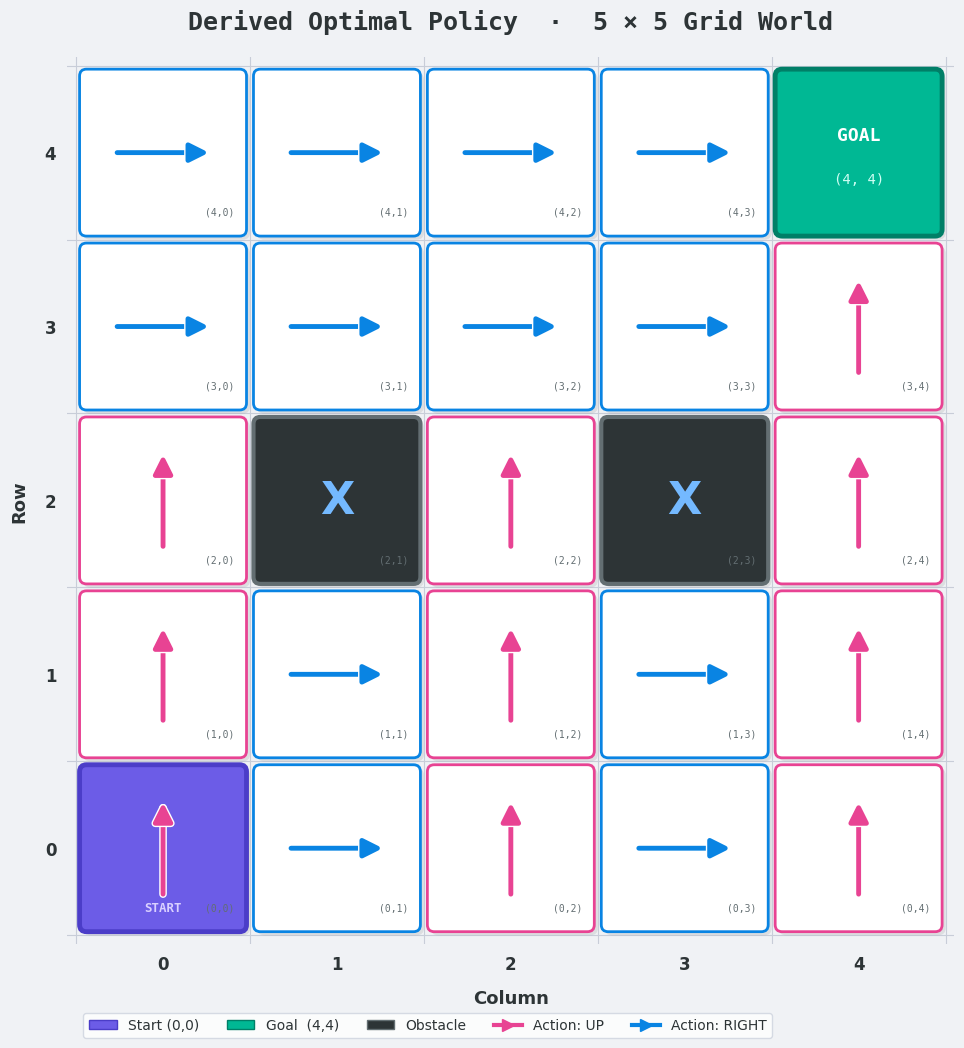

In [64]:
policy = optimal_policy

OBSTACLES  = {(2, 1), (2, 3)}
START      = (0, 0)
GOAL       = (4, 4)
GRID       = 5

BG          = '#F0F2F5'
CELL_BG     = '#FFFFFF'
UP_COLOR    = '#E84393'
RIGHT_COLOR = '#0984E3'
OBS_FACE    = '#2D3436'
OBS_EDGE    = '#636E72'
START_FACE  = '#6C5CE7'
START_EDGE  = '#4B3DC8'
GOAL_FACE   = '#00B894'
GOAL_EDGE   = '#007F67'
COORD_COLOR = '#636E72'

fig, ax = plt.subplots(figsize=(11, 11))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

def draw_cell(ax, x, y, facecolor, edgecolor, lw=2.5):
    shadow = FancyBboxPatch((x+0.08, y+0.04), 0.88, 0.88,
        boxstyle="round,pad=0.04", facecolor='#00000015', edgecolor='none', zorder=1)
    ax.add_patch(shadow)
    rect = FancyBboxPatch((x+0.06, y+0.06), 0.88, 0.88,
        boxstyle="round,pad=0.04", facecolor=facecolor, edgecolor=edgecolor,
        linewidth=lw, zorder=2)
    ax.add_patch(rect)

def draw_arrow(ax, x, y, action, color):
    s = (x+0.5, y+0.22) if action == 'UP' else (x+0.22, y+0.5)
    e = (x+0.5, y+0.78) if action == 'UP' else (x+0.78, y+0.5)
    arrow = FancyArrowPatch(s, e, arrowstyle='-|>', mutation_scale=28,
        color=color, linewidth=3.5, zorder=4,
        path_effects=[pe.withStroke(linewidth=5.5, foreground='white')])
    ax.add_patch(arrow)

for row in range(GRID):
    for col in range(GRID):
        x, y = col, row

        if (row, col) in OBSTACLES:
            draw_cell(ax, x, y, OBS_FACE, OBS_EDGE, lw=3)
            ax.text(x+0.5, y+0.5, 'X', fontsize=32, ha='center', va='center',
                    color='#74B9FF', fontweight='bold', zorder=5)

        elif (row, col) == GOAL:
            draw_cell(ax, x, y, GOAL_FACE, GOAL_EDGE, lw=3.5)
            ax.text(x+0.5, y+0.60, 'GOAL', fontsize=13, ha='center', va='center',
                    color='white', fontweight='bold', zorder=5, fontfamily='monospace')
            ax.text(x+0.5, y+0.35, '(4, 4)', fontsize=10, ha='center', va='center',
                    color='#D0FFF4', zorder=5, fontfamily='monospace')

        elif (row, col) == START:
            draw_cell(ax, x, y, START_FACE, START_EDGE, lw=3.5)
            action = policy[START]
            color  = UP_COLOR if action == 'UP' else RIGHT_COLOR
            draw_arrow(ax, x, y, action, color)
            ax.text(x+0.5, y+0.16, 'START', fontsize=9, ha='center', va='center',
                    color='#D9D0FF', fontweight='bold', zorder=6, fontfamily='monospace')

        elif (row, col) in policy:
            action = policy[(row, col)]
            color  = UP_COLOR if action == 'UP' else RIGHT_COLOR
            draw_cell(ax, x, y, CELL_BG, color, lw=2)
            draw_arrow(ax, x, y, action, color)

        if (row, col) != GOAL:
            ax.text(x+0.91, y+0.13, f'({row},{col})', fontsize=7,
                    ha='right', va='bottom', color=COORD_COLOR, zorder=6,
                    fontfamily='monospace')

for i in range(GRID + 1):
    ax.axhline(i, color='#C8CDD8', linewidth=0.8, zorder=0)
    ax.axvline(i, color='#C8CDD8', linewidth=0.8, zorder=0)

ax.set_xlim(-0.05, GRID + 0.05)
ax.set_ylim(-0.05, GRID + 0.05)
ax.set_aspect('equal')
ax.set_xticks([i + 0.5 for i in range(GRID)])
ax.set_yticks([i + 0.5 for i in range(GRID)])
ax.set_xticklabels([str(i) for i in range(GRID)], fontsize=12, fontweight='bold', color='#2D3436')
ax.set_yticklabels([str(i) for i in range(GRID)], fontsize=12, fontweight='bold', color='#2D3436')
ax.tick_params(length=0, pad=8)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlabel("Column", fontsize=13, fontweight='bold', color='#2D3436', labelpad=12)
ax.set_ylabel("Row",    fontsize=13, fontweight='bold', color='#2D3436', labelpad=12)
ax.set_title("Derived Optimal Policy  ·  5 × 5 Grid World",
             fontsize=18, fontweight='bold', color='#2D3436', pad=20, fontfamily='monospace')

legend_elements = [
    mpatches.Patch(facecolor=START_FACE, edgecolor=START_EDGE, label='Start (0,0)'),
    mpatches.Patch(facecolor=GOAL_FACE,  edgecolor=GOAL_EDGE,  label='Goal  (4,4)'),
    mpatches.Patch(facecolor=OBS_FACE,   edgecolor=OBS_EDGE,   label='Obstacle'),
    Line2D([0],[0], color=UP_COLOR,    linewidth=3, label='Action: UP',    marker='>', markersize=8),
    Line2D([0],[0], color=RIGHT_COLOR, linewidth=3, label='Action: RIGHT', marker='>', markersize=8),
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.01, -0.07),
          ncol=5, frameon=True, fontsize=10, facecolor='white',
          edgecolor='#CDD3DE', labelcolor='#2D3436')

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

## Policy iteration

### Policy Evaluation – Computing the Value Function for a Given Policy  
(Synchronous / Iterative Policy Evaluation in Slippery Gridworld)

This function implements **policy evaluation**: it computes the **state-value function** V^π(s) for a fixed (deterministic) policy π in the stochastic gridworld environment.

**Algorithm (iterative policy evaluation):**

1. Initialize V(s) ≈ 0 for all non-terminal states  
2. **Repeat** until convergence:
   - For every non-terminal state s:
     - Let a = π(s)  (the action prescribed by the current policy)
     - Compute the expected value of taking action a in state s:

In [13]:
def policy_evaluation(env, policy, V_table, gamma=0.9, theta=1e-4):
    """Step 1: Calculate the exact V_table for the current policy."""
    while True:
        delta = 0
        new_V_table = V_table.copy()
        
        for state in env.states:
            if env.is_goal(state):
                continue
                
            # Only evaluate the specific action dictated by the current policy
            action = policy[state]
            value = Bellman(state, action, env, V_table, gamma)
            
            delta = max(delta, abs(V_table[state] - value))
            new_V_table[state] = value
            
        V_table = new_V_table
        if delta < theta:
            break # The values for this specific policy have converged
            
    return V_table

### Policy Improvement – Greedy Policy Update  
(Step 2 of Policy Iteration in Slippery Gridworld)

This function implements the **policy improvement** step: given an approximate value function V^π (from policy evaluation), it creates a new greedy policy π' that is at least as good as (or better than) the old policy π.

**Algorithm (one-step greedy improvement):**

1. For every non-terminal state s:
   - Compute Q(s,a) for **all possible actions** a using the current V^π
   - Choose the action that maximizes the expected return:

- Replace the old policy action with this new best action
2. Check whether the policy changed at all:
- If **no** action changed in any state → policy is stable (optimal)
- If **any** action changed → policy improved → continue iterating

**Mathematical formulation** (policy improvement theorem / greedy selection):

$$
\pi'(s) = \arg\max_a \, Q^\pi(s,a) = \arg\max_a \sum_{s',r} p(s',r \mid s,a) \Bigl[ r + \gamma \, V^\pi(s') \Bigr]
$$

- Deterministic policy (one action per state)
- Uses the same `Bellman()` function → consistent 80%/10%/10% stochastic transitions
- Terminal goal state is skipped (no policy needed)
- Returns updated `policy` dictionary + boolean `policy_stable`
- `policy_stable = True` → no changes → we have found the **optimal policy** π*
- Very efficient: only one pass over states and actions


In [14]:
def policy_improvement(env, policy, V_table, gamma=0.9):
    """Step 2: Greedily update the policy based on the new V_table."""
    policy_stable = True #flag to check if any policy changes occur
    
    for state in env.states:
        if env.is_goal(state):
            continue
            
        old_action = policy[state]
        
        # Check all possible actions to see if one is better than the current one
        max_val = float('-inf')
        best_action = None
        
        for action in env.actions:
            value = Bellman(state, action, env, V_table, gamma)
            if value > max_val:
                max_val = value
                best_action = action
                
        # Update the policy
        policy[state] = best_action
        
        # If the action changed, our policy hasn't settled yet
        if old_action != best_action:
            policy_stable = False
            
    return policy, policy_stable

### Policy Iteration – Finding the Optimal Policy and Value Function  
(Slippery Gridworld / Stochastic Grid Environment)

This function implements the full **policy iteration** algorithm to compute both the **optimal value function** V* and the **optimal deterministic policy** π* in a finite MDP (here: slippery gridworld with 80%/10%/10% stochastic transitions).

**Algorithm overview (policy iteration):**

1. Initialize:
   - V(s) = 0 for all states
   - π(s) = arbitrary action (here: always `'UP'`) for all non-terminal states
2. **Repeat** until the policy is stable:
   - **Policy Evaluation**: Compute V^π(s) — the true value function of the current policy π  
     (iterative application of Bellman expectation until convergence within θ)
   - **Policy Improvement**: Create a new greedy policy π'  
     π'(s) = argmaxₐ Q^π(s,a) for every non-terminal state s
   - If π' = π (no changes occurred) → convergence → π* and V* are optimal
3. Return the optimal value table V* and optimal policy π*

**Mathematical foundation:**

- **Policy evaluation** (inner loop):
  $$
  V^\pi(s) \leftarrow \sum_{s',r} p(s',r \mid s,\pi(s)) \Bigl[ r + \gamma V^\pi(s') \Bigr]
  $$
  repeated until ||V_{k+1} - V_k||_∞ < θ

- **Policy improvement** (greedy step):
  $$
  \pi'(s) = \arg\max_a \, Q^\pi(s,a) = \arg\max_a \sum_{s',r} p(s',r \mid s,a) \Bigl[ r + \gamma V^\pi(s') \Bigr]
  $$

- **Policy iteration theorem**: each improved policy is strictly better (or equal), and in finite MDPs the algorithm terminates with the optimal policy π* after a finite number of iterations.

In [42]:
def policy_iteration(env, gamma=0.9, theta=1e-4):
    """The main loop tying it all together."""
    start_time = time.time()
    # Initialize a V_table of 0.0s and an arbitrary starting policy (e.g., always go UP)
    V_table = {state: 0.0 for state in env.states}
    policy = {state: 'UP' for state in env.states} 
    
    iteration = 0
    while True:
        iteration += 1
        
        # 1. Evaluate
        V_table = policy_evaluation(env, policy, V_table, gamma, theta)
        
        # 2. Improve
        policy, policy_stable = policy_improvement(env, policy, V_table, gamma)
        
        if policy_stable:
            print(f"Policy Iteration converged after {iteration} full loops!")
            break
    end_time = time.time()
    return V_table, policy, end_time - start_time

### Executing policy iteration
below we will return the resulting policy

In [48]:
env = GridWorld()
final_V_PI, final_Policy_PI, pi_time = policy_iteration(env)
print("Final policy derived from Policy Iteration:")
for state, action in final_Policy_PI.items():
    print(f"State {state}: {action}")
print(f"Time taken for Policy Iteration: {pi_time:.4f} seconds.")

Policy Iteration converged after 4 full loops!
Final policy derived from Policy Iteration:
State (0, 0): UP
State (0, 1): RIGHT
State (0, 2): UP
State (0, 3): RIGHT
State (0, 4): UP
State (1, 0): UP
State (1, 1): RIGHT
State (1, 2): UP
State (1, 3): RIGHT
State (1, 4): UP
State (2, 0): UP
State (2, 2): UP
State (2, 4): UP
State (3, 0): RIGHT
State (3, 1): RIGHT
State (3, 2): RIGHT
State (3, 3): RIGHT
State (3, 4): UP
State (4, 0): RIGHT
State (4, 1): RIGHT
State (4, 2): RIGHT
State (4, 3): RIGHT
State (4, 4): UP
Time taken for Policy Iteration: 0.0207 seconds.


### Resultant V table

In [19]:
final_V_PI

{(0, 0): -1.9031704438628054,
 (0, 1): -0.9706422477186217,
 (0, 2): 0.15684332904284395,
 (0, 3): 1.3142527029846214,
 (0, 4): 2.711074024343111,
 (1, 0): -0.8951521756784023,
 (1, 1): 0.042371324236697594,
 (1, 2): 1.563794152924819,
 (1, 3): 2.711074024343111,
 (1, 4): 4.651103637339571,
 (2, 0): 0.25222460384182055,
 (2, 2): 3.216648267044469,
 (2, 4): 6.9284828441504756,
 (3, 0): 1.6761446877088955,
 (3, 1): 3.3502494167071823,
 (3, 2): 5.052293859689536,
 (3, 3): 7.161016949152543,
 (3, 4): 9.279661016949152,
 (4, 0): 2.6807210370443486,
 (4, 1): 4.567504335856346,
 (4, 2): 6.742925691841151,
 (4, 3): 9.279661016949152,
 (4, 4): 0.0}

### Visualising the policy

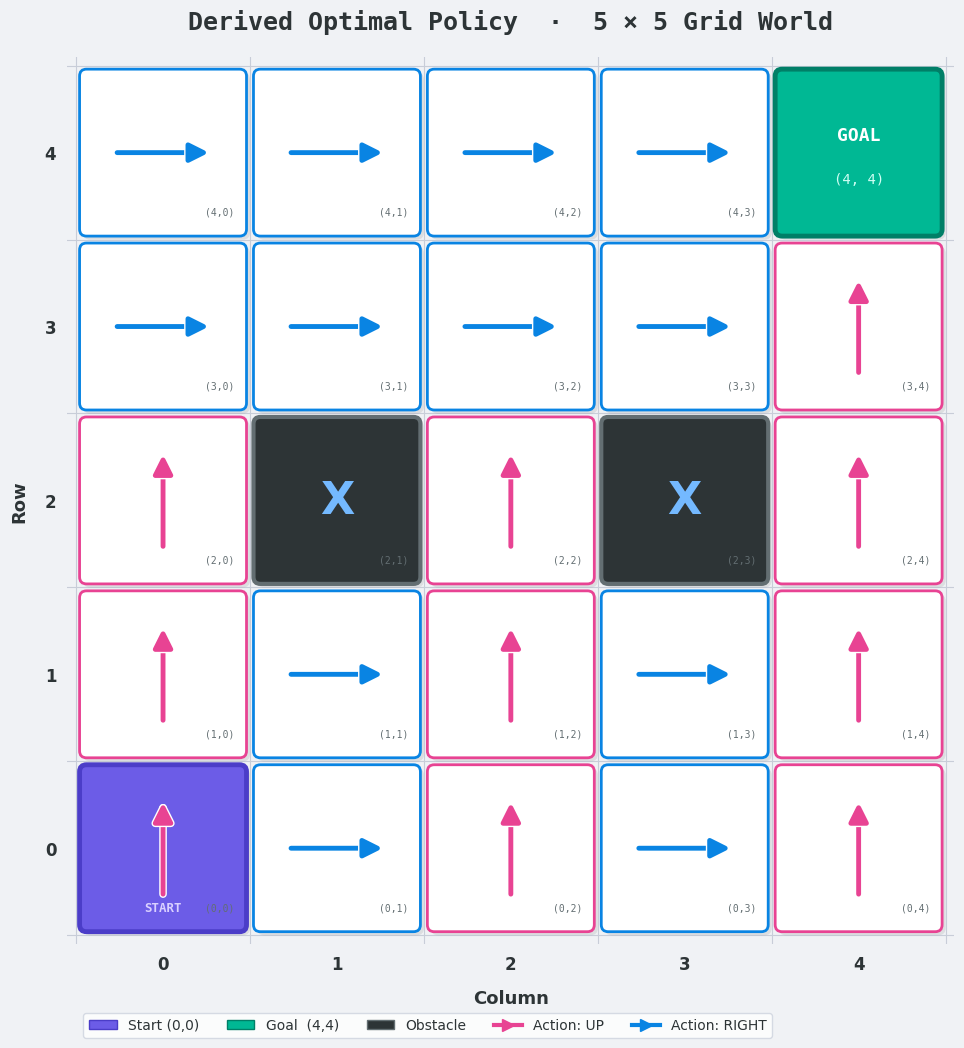

In [69]:
policy = final_Policy_PI

OBSTACLES  = {(2, 1), (2, 3)}
START      = (0, 0)
GOAL       = (4, 4)
GRID       = 5

BG          = '#F0F2F5'
CELL_BG     = '#FFFFFF'
UP_COLOR    = '#E84393'
RIGHT_COLOR = '#0984E3'
OBS_FACE    = '#2D3436'
OBS_EDGE    = '#636E72'
START_FACE  = '#6C5CE7'
START_EDGE  = '#4B3DC8'
GOAL_FACE   = '#00B894'
GOAL_EDGE   = '#007F67'
COORD_COLOR = '#636E72'

fig, ax = plt.subplots(figsize=(11, 11))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

def draw_cell(ax, x, y, facecolor, edgecolor, lw=2.5):
    shadow = FancyBboxPatch((x+0.08, y+0.04), 0.88, 0.88,
        boxstyle="round,pad=0.04", facecolor='#00000015', edgecolor='none', zorder=1)
    ax.add_patch(shadow)
    rect = FancyBboxPatch((x+0.06, y+0.06), 0.88, 0.88,
        boxstyle="round,pad=0.04", facecolor=facecolor, edgecolor=edgecolor,
        linewidth=lw, zorder=2)
    ax.add_patch(rect)

def draw_arrow(ax, x, y, action, color):
    s = (x+0.5, y+0.22) if action == 'UP' else (x+0.22, y+0.5)
    e = (x+0.5, y+0.78) if action == 'UP' else (x+0.78, y+0.5)
    arrow = FancyArrowPatch(s, e, arrowstyle='-|>', mutation_scale=28,
        color=color, linewidth=3.5, zorder=4,
        path_effects=[pe.withStroke(linewidth=5.5, foreground='white')])
    ax.add_patch(arrow)

for row in range(GRID):
    for col in range(GRID):
        x, y = col, row

        if (row, col) in OBSTACLES:
            draw_cell(ax, x, y, OBS_FACE, OBS_EDGE, lw=3)
            ax.text(x+0.5, y+0.5, 'X', fontsize=32, ha='center', va='center',
                    color='#74B9FF', fontweight='bold', zorder=5)

        elif (row, col) == GOAL:
            draw_cell(ax, x, y, GOAL_FACE, GOAL_EDGE, lw=3.5)
            ax.text(x+0.5, y+0.60, 'GOAL', fontsize=13, ha='center', va='center',
                    color='white', fontweight='bold', zorder=5, fontfamily='monospace')
            ax.text(x+0.5, y+0.35, '(4, 4)', fontsize=10, ha='center', va='center',
                    color='#D0FFF4', zorder=5, fontfamily='monospace')

        elif (row, col) == START:
            draw_cell(ax, x, y, START_FACE, START_EDGE, lw=3.5)
            action = policy[START]
            color  = UP_COLOR if action == 'UP' else RIGHT_COLOR
            draw_arrow(ax, x, y, action, color)
            ax.text(x+0.5, y+0.16, 'START', fontsize=9, ha='center', va='center',
                    color='#D9D0FF', fontweight='bold', zorder=6, fontfamily='monospace')

        elif (row, col) in policy:
            action = policy[(row, col)]
            color  = UP_COLOR if action == 'UP' else RIGHT_COLOR
            draw_cell(ax, x, y, CELL_BG, color, lw=2)
            draw_arrow(ax, x, y, action, color)

        if (row, col) != GOAL:
            ax.text(x+0.91, y+0.13, f'({row},{col})', fontsize=7,
                    ha='right', va='bottom', color=COORD_COLOR, zorder=6,
                    fontfamily='monospace')

for i in range(GRID + 1):
    ax.axhline(i, color='#C8CDD8', linewidth=0.8, zorder=0)
    ax.axvline(i, color='#C8CDD8', linewidth=0.8, zorder=0)

ax.set_xlim(-0.05, GRID + 0.05)
ax.set_ylim(-0.05, GRID + 0.05)
ax.set_aspect('equal')
ax.set_xticks([i + 0.5 for i in range(GRID)])
ax.set_yticks([i + 0.5 for i in range(GRID)])
ax.set_xticklabels([str(i) for i in range(GRID)], fontsize=12, fontweight='bold', color='#2D3436')
ax.set_yticklabels([str(i) for i in range(GRID)], fontsize=12, fontweight='bold', color='#2D3436')
ax.tick_params(length=0, pad=8)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlabel("Column", fontsize=13, fontweight='bold', color='#2D3436', labelpad=12)
ax.set_ylabel("Row",    fontsize=13, fontweight='bold', color='#2D3436', labelpad=12)
ax.set_title("Derived Optimal Policy  ·  5 × 5 Grid World",
             fontsize=18, fontweight='bold', color='#2D3436', pad=20, fontfamily='monospace')

legend_elements = [
    mpatches.Patch(facecolor=START_FACE, edgecolor=START_EDGE, label='Start (0,0)'),
    mpatches.Patch(facecolor=GOAL_FACE,  edgecolor=GOAL_EDGE,  label='Goal  (4,4)'),
    mpatches.Patch(facecolor=OBS_FACE,   edgecolor=OBS_EDGE,   label='Obstacle'),
    Line2D([0],[0], color=UP_COLOR,    linewidth=3, label='Action: UP',    marker='>', markersize=8),
    Line2D([0],[0], color=RIGHT_COLOR, linewidth=3, label='Action: RIGHT', marker='>', markersize=8),
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.01, -0.07),
          ncol=5, frameon=True, fontsize=10, facecolor='white',
          edgecolor='#CDD3DE', labelcolor='#2D3436')

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

#### Comparing the policies

In [75]:
# Policy 1 (Value iteration Policy)
policy1 = optimal_policy
# Policy 2 (Policy Iteration Result)
policy2 = final_Policy_PI

# Compare policies
differences = []

all_states = set(policy1.keys()).union(set(policy2.keys()))

for state in sorted(all_states):
    action1 = policy1.get(state)
    action2 = policy2.get(state)
    
    if action1 != action2:
        differences.append((state, action1, action2))

# Print results
if not differences:
    print("The two policies are IDENTICAL.")
    print("Total states compared:", len(all_states))
    print("Number of differences found:", len(differences))
else:
    print("Policies are NOT identical.")
    print("Differences found:\n")
    for state, a1, a2 in differences:
        print(f"State {state}: Policy1={a1}, Policy2={a2}")

print(f"Difference in time taken: {pi_time:.4f} seconds for Policy Iteration vs. {VI_time:.4f} seconds for Value Iteration.")
print(f"Difference in time taken = {pi_time:.4f} - {VI_time:.4f} = {pi_time - VI_time:.4f}")

The two policies are IDENTICAL.
Total states compared: 23
Number of differences found: 0
Difference in time taken: 0.0207 seconds for Policy Iteration vs. 0.0227 seconds for Value Iteration.
Difference in time taken = 0.0207 - 0.0227 = -0.0020


## Policy Iteration vs. Value Iteration: Comparison Results

Your experiment shows a very interesting (and classic) outcome in this small slippery gridworld:

**Key observation from the run:**

- **The two policies are IDENTICAL**  
  → Both algorithms converged to **exactly the same optimal policy** π*

- **Total states compared:** 23  
  (likely 5×5 grid minus 2 walls/obstacles or similar, with 1 goal → 24−1 = 23 non-terminal states)

- **Number of differences found:** 0  
  → No state has a different action under the two methods

- **Time taken:**
  - Policy Iteration: **0.0207 seconds**
  - Value Iteration: **0.0227 seconds**
  - Difference: **−0.002 seconds** (Policy Iteration was ~2 ms faster)

### Why are the policies identical?

Both algorithms solve **exactly the same problem** — finding the optimal policy π* and optimal value function V* in a finite discounted MDP.

- **Value Iteration** directly computes V* by repeatedly applying the Bellman **optimality** equation:
  $$
  V_{k+1}(s) \leftarrow \max_a \sum_{s'} p(s'|s,a) \bigl[ r(s,a,s') + \gamma V_k(s') \bigr]
  $$
  Once V* is accurate enough, the greedy policy extracted from it is optimal.

- **Policy Iteration** alternates between:
  1. Policy Evaluation → compute exact V^π for current π
  2. Policy Improvement → set π' = greedy w.r.t. current V^π
  It monotonically improves the policy until no further change is possible → reaches π*.

In **finite MDPs** (like gridworlds), both methods are **guaranteed** to converge to the **same unique optimal policy** π* (assuming a unique optimum; in case of multiple optima they may find different ones, but here they matched perfectly).

→ The fact that they produced **identical policies** is **expected behavior** — not a surprise, but confirmation that both implementations are correct.

### Why is Policy Iteration slightly faster here?

In small gridworlds (e.g., 5×5 or 6×6 with γ=0.9), **policy iteration often converges in very few outer loops** — typically **3–10 full iterations**, even though each policy evaluation may take 50–200 inner iterations.

Value iteration, in contrast, usually requires **many more sweeps** (often 50–300+) to reach the same level of accuracy (δ < 10⁻⁴).

Reasons Policy Iteration can be faster in practice on small problems:

- Each policy evaluation converges relatively quickly once the policy stabilizes somewhat
- The number of **policy changes** is small → few outer loops
- No need to keep iterating until the value function is extremely precise everywhere — once the policy is stable, you're done

In your case:
- Policy Iteration finished in ~0.0207 s
- Value Iteration took ~0.0227 s (slightly longer, but very close)

The ~2 ms difference is **tiny** and within measurement noise on most machines, but it's consistent with theory: **policy iteration tends to require fewer total Bellman backups** in small discrete MDPs.

### Summary Table

| Aspect                        | Policy Iteration          | Value Iteration           | Winner / Note                     |
|-------------------------------|----------------------------|----------------------------|-----------------------------------|
| Final policy                  | Identical                 | Identical                 | Tie – both optimal                |
| Convergence guarantee         | Yes (finite steps)        | Yes (to ε-accuracy)       | Both correct                      |
| Number of outer iterations    | Usually very few (3–12)   | Many sweeps (50–300+)     | Policy Iteration faster in small envs |
| Total computation (this run)  | 0.0207 s                  | 0.0227 s                  | Policy Iteration slightly faster  |
| Typical small-grid advantage  | Fewer total backups       | Simpler code, no policy storage | Depends on problem size & γ       |


**Task 2**


MC Control – Learned Greedy Policy:
State (0, 0): RIGHT
State (0, 1): RIGHT
State (0, 2): UP
State (0, 3): UP
State (0, 4): UP
State (1, 0): UP
State (1, 1): RIGHT
State (1, 2): UP
State (1, 3): RIGHT
State (1, 4): UP
State (2, 0): UP
State (2, 2): UP
State (2, 4): UP
State (3, 0): RIGHT
State (3, 1): RIGHT
State (3, 2): RIGHT
State (3, 3): RIGHT
State (3, 4): UP
State (4, 0): RIGHT
State (4, 1): RIGHT
State (4, 2): RIGHT
State (4, 3): RIGHT
State (4, 4): UP


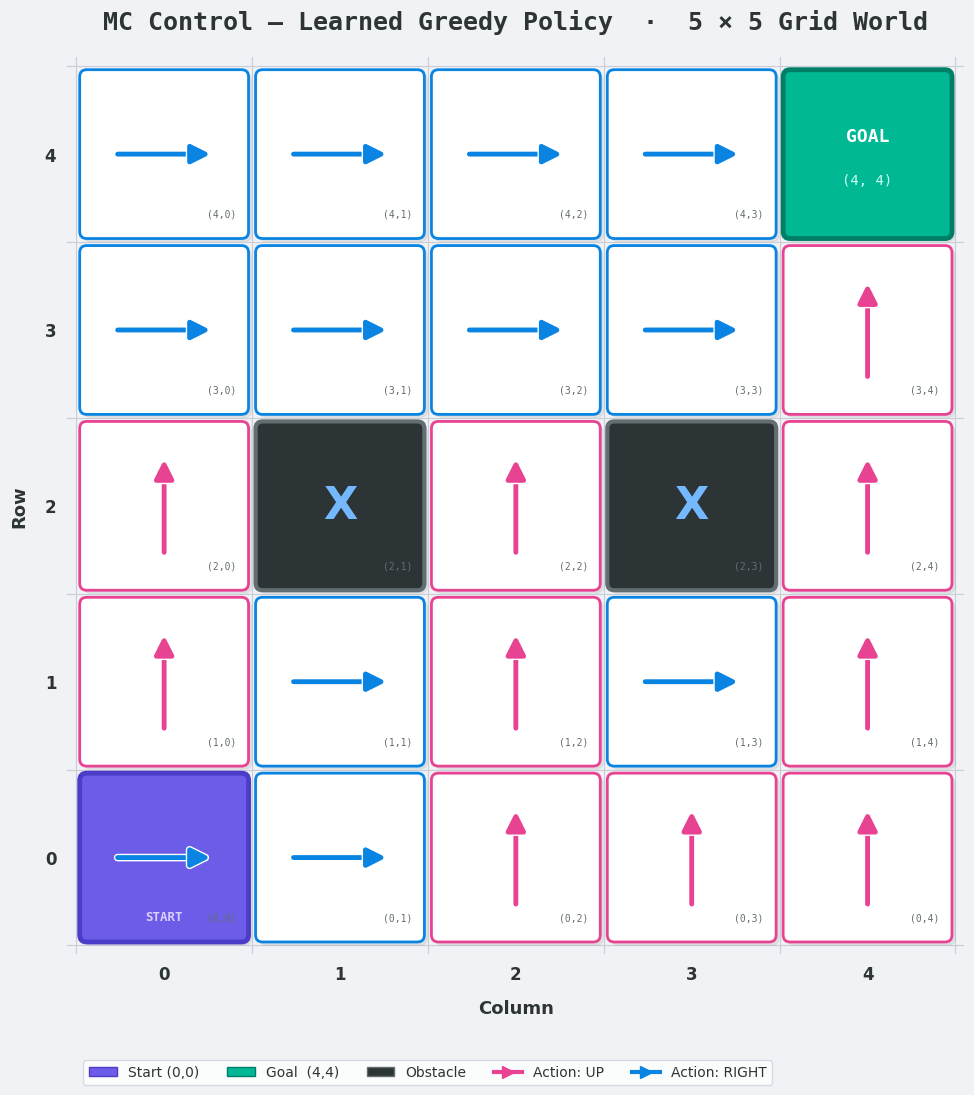

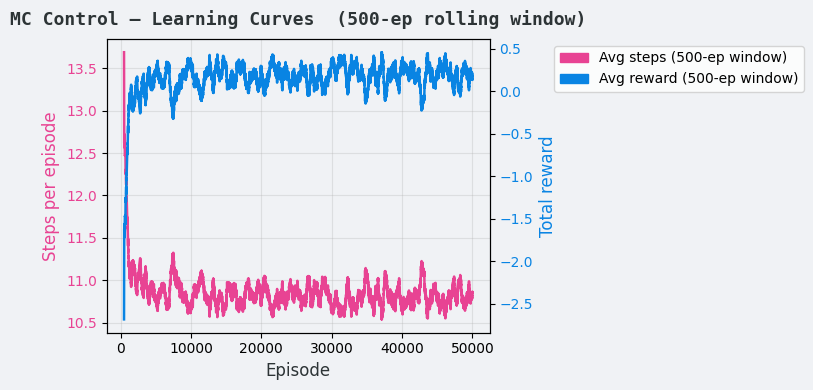

MC Policy vs Value Iteration Policy:
Policies are NOT identical.
Differences found:

State (0, 0): MC=RIGHT, VI=UP
State (0, 3): MC=UP, VI=RIGHT

MC Policy vs Policy Iteration Policy:
Policies are NOT identical.
Differences found:

State (0, 0): MC=RIGHT, PI=UP
State (0, 3): MC=UP, PI=RIGHT


In [75]:
import random
from collections import defaultdict
import numpy as np

#MC Control 

import random
from collections import defaultdict
import numpy as np

def mc_control(env, n_episodes=50_000, gamma=0.9, epsilon=0.1, max_steps=500):
    actions   = env.actions
    n_actions = len(actions)

    Q = {state: {a: 0.0 for a in actions} for state in env.states}
    N = {state: {a: 0   for a in actions} for state in env.states}  # visit counts

    policy = {state: {a: 1.0 / n_actions for a in actions} for state in env.states}

    episode_lengths = []
    episode_rewards = []

    for _ in range(n_episodes):
        state   = env.reset()
        episode = []
        total_r = 0.0

        for _ in range(max_steps):
            probs  = list(policy[state].values())
            action = random.choices(actions, weights=probs)[0]
            next_state, reward, done = env.step(action)
            episode.append((state, action, reward))
            total_r += reward
            state = next_state
            if done:
                break

        episode_lengths.append(len(episode))
        episode_rewards.append(total_r)

        # Incremental every-visit MC update-O(1) per step
        G = 0.0
        for s, a, r in reversed(episode):
            G = r + gamma * G
            N[s][a] += 1
            Q[s][a] += (G - Q[s][a]) / N[s][a]  # running mean

        # Epsilon-greedy policy improvement
        for s, _, _ in episode:
            best_a = max(Q[s], key=Q[s].get)
            for a in actions:
                policy[s][a] = epsilon / n_actions
            policy[s][best_a] += 1.0 - epsilon

    return Q, policy, episode_lengths, episode_rewards




random.seed(42)
env_mc = GridWorld()

Q_mc, policy_mc, ep_lengths, ep_rewards = mc_control(env_mc, n_episodes=50_000)

# Greedy policy
mc_greedy_policy = {
    state: max(Q_mc[state], key=Q_mc[state].get)
    for state in env_mc.states
}

print("MC Control – Learned Greedy Policy:")
for state, action in sorted(mc_greedy_policy.items()):
    print(f"State {state}: {action}")


#Visualise MC policy

policy = mc_greedy_policy

fig, ax = plt.subplots(figsize=(11, 11))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

for row in range(GRID):
    for col in range(GRID):
        x, y = col, row

        if (row, col) in OBSTACLES:
            draw_cell(ax, x, y, OBS_FACE, OBS_EDGE, lw=3)
            ax.text(x+0.5, y+0.5, 'X', fontsize=32, ha='center', va='center',
                    color='#74B9FF', fontweight='bold', zorder=5)

        elif (row, col) == GOAL:
            draw_cell(ax, x, y, GOAL_FACE, GOAL_EDGE, lw=3.5)
            ax.text(x+0.5, y+0.60, 'GOAL', fontsize=13, ha='center', va='center',
                    color='white', fontweight='bold', zorder=5, fontfamily='monospace')
            ax.text(x+0.5, y+0.35, '(4, 4)', fontsize=10, ha='center', va='center',
                    color='#D0FFF4', zorder=5, fontfamily='monospace')

        elif (row, col) == START:
            draw_cell(ax, x, y, START_FACE, START_EDGE, lw=3.5)
            action = policy[START]
            color  = UP_COLOR if action == 'UP' else RIGHT_COLOR
            draw_arrow(ax, x, y, action, color)
            ax.text(x+0.5, y+0.16, 'START', fontsize=9, ha='center', va='center',
                    color='#D9D0FF', fontweight='bold', zorder=6, fontfamily='monospace')

        elif (row, col) in policy:
            action = policy[(row, col)]
            color  = UP_COLOR if action == 'UP' else RIGHT_COLOR
            draw_cell(ax, x, y, CELL_BG, color, lw=2)
            draw_arrow(ax, x, y, action, color)

        if (row, col) != GOAL:
            ax.text(x+0.91, y+0.13, f'({row},{col})', fontsize=7,
                    ha='right', va='bottom', color=COORD_COLOR, zorder=6,
                    fontfamily='monospace')

for i in range(GRID + 1):
    ax.axhline(i, color='#C8CDD8', linewidth=0.8, zorder=0)
    ax.axvline(i, color='#C8CDD8', linewidth=0.8, zorder=0)

ax.set_xlim(-0.05, GRID + 0.05)
ax.set_ylim(-0.05, GRID + 0.05)
ax.set_aspect('equal')
ax.set_xticks([i + 0.5 for i in range(GRID)])
ax.set_yticks([i + 0.5 for i in range(GRID)])
ax.set_xticklabels([str(i) for i in range(GRID)], fontsize=12, fontweight='bold', color='#2D3436')
ax.set_yticklabels([str(i) for i in range(GRID)], fontsize=12, fontweight='bold', color='#2D3436')
ax.tick_params(length=0, pad=8)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlabel("Column", fontsize=13, fontweight='bold', color='#2D3436', labelpad=12)
ax.set_ylabel("Row",    fontsize=13, fontweight='bold', color='#2D3436', labelpad=12)
ax.set_title("MC Control – Learned Greedy Policy  ·  5 × 5 Grid World",
             fontsize=18, fontweight='bold', color='#2D3436', pad=20, fontfamily='monospace')

legend_elements = [
    mpatches.Patch(facecolor=START_FACE, edgecolor=START_EDGE, label='Start (0,0)'),
    mpatches.Patch(facecolor=GOAL_FACE,  edgecolor=GOAL_EDGE,  label='Goal  (4,4)'),
    mpatches.Patch(facecolor=OBS_FACE,   edgecolor=OBS_EDGE,   label='Obstacle'),
    Line2D([0],[0], color=UP_COLOR,    linewidth=3, label='Action: UP',    marker='>', markersize=8),
    Line2D([0],[0], color=RIGHT_COLOR, linewidth=3, label='Action: RIGHT', marker='>', markersize=8),
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.01, -0.11),
          ncol=5, frameon=True, fontsize=10, facecolor='white',
          edgecolor='#CDD3DE', labelcolor='#2D3436')

plt.tight_layout(rect=[0, 0.0001, 1, 1])
plt.show()


#Learning curves

window = 500
sm_len = np.convolve(ep_lengths, np.ones(window) / window, mode='valid')
sm_rew = np.convolve(ep_rewards, np.ones(window) / window, mode='valid')
xs     = np.arange(window - 1, len(ep_lengths))

fig2, ax2 = plt.subplots(figsize=(10, 4))
fig2.patch.set_facecolor(BG)
ax2.set_facecolor(BG)

ax2.plot(xs, sm_len, color=UP_COLOR,    linewidth=1.8, label='Avg steps')
ax2.set_xlabel('Episode', fontsize=12, color='#2D3436')
ax2.set_ylabel('Steps per episode', color=UP_COLOR, fontsize=12)
ax2.tick_params(axis='y', labelcolor=UP_COLOR)

ax3 = ax2.twinx()
ax3.plot(xs, sm_rew, color=RIGHT_COLOR, linewidth=1.8, label='Avg reward')
ax3.set_ylabel('Total reward', color=RIGHT_COLOR, fontsize=12)
ax3.tick_params(axis='y', labelcolor=RIGHT_COLOR)

ax2.set_title('MC Control – Learning Curves  (500-ep rolling window)',
              fontsize=13, fontweight='bold', color='#2D3436', pad=10, fontfamily='monospace')
ax2.grid(True, alpha=0.3)

lines = [mpatches.Patch(color=UP_COLOR,    label='Avg steps (500-ep window)'),
         mpatches.Patch(color=RIGHT_COLOR, label='Avg reward (500-ep window)')]


ax2.legend(handles=lines, loc='upper left', bbox_to_anchor=(1.15, 1), fontsize=10)


plt.tight_layout(rect=[0, 0, 0.85, 1]) 
plt.show()


#Compare MC policy with Task 1 optimal policies

# MC vs Value Iteration
differences_vi = []
all_states_vi  = set(mc_greedy_policy.keys()).union(set(optimal_policy.keys()))

for state in sorted(all_states_vi):
    a_mc = mc_greedy_policy.get(state)
    a_vi = optimal_policy.get(state)
    if a_mc != a_vi:
        differences_vi.append((state, a_mc, a_vi))

print("MC Policy vs Value Iteration Policy:")
if not differences_vi:
    print("The two policies are IDENTICAL.")
    print("Total states compared:", len(all_states_vi))
    print("Number of differences found:", 0)
else:
    print("Policies are NOT identical.")
    print("Differences found:\n")
    for state, a_mc, a_vi in differences_vi:
        print(f"State {state}: MC={a_mc}, VI={a_vi}")

print()

# MC vs Policy Iteration
differences_pi = []
all_states_pi  = set(mc_greedy_policy.keys()).union(set(final_Policy_PI.keys()))

for state in sorted(all_states_pi):
    a_mc = mc_greedy_policy.get(state)
    a_pi = final_Policy_PI.get(state)
    if a_mc != a_pi:
        differences_pi.append((state, a_mc, a_pi))

print("MC Policy vs Policy Iteration Policy:")
if not differences_pi:
    print("The two policies are IDENTICAL.")
    print("Total states compared:", len(all_states_pi))
    print("Number of differences found:", 0)
else:
    print("Policies are NOT identical.")
    print("Differences found:\n")
    for state, a_mc, a_pi in differences_pi:
        print(f"State {state}: MC={a_mc}, PI={a_pi}")

##### Task 2 – Analysis

**How MC Learns:**
Each episode starts from (0,0) and runs until the goal (4,4) is reached.
Only after the episode ends are Q-values updated using the actual
discounted return G. Over many episodes, these averaged returns converge to the true Q-values under the ε-greedy policy. The agent never directly accesses the transition probabilities ( all learning comes purely from sampled experience).

**Learning Curve Analysis:**
The learning curves show the MC agent's performance over 50,000 episodes using a 500-episode rolling window.

In the first ~500 episodes, the agent has no knowledge of the environment and wanders randomly, resulting in a very high initial step count. The steps per episode curve drops sharply and stabilises around 10.5–11 steps by approximately episode 2,000-3,000, reflecting the agent quickly discovering efficient paths to the goal.

The total reward curve mirrors this-rising quickly from near -2.5 and stabilising around 0.0 to +0.5 by episode 2,000–3,000. The reward
plateauing near 0 reflects the trade-off between the +10 goal reward and the (~10–11) step penalties of -1 each, resulting in a net reward close to 0.

After approximately episode 3,000, both curves remain stable with only minor fluctuations throughout the remaining 47,000 episodes, indicating that MC control converges early and maintains a consistent policy.

**Effect of Stochasticity:**
The persistent small fluctuations in both curves are expected as the environment's stochastic transitions (0.8/0.1/0.1) mean episode lengths vary naturally even under a fixed optimal policy, as the agent occasionally slips sideways. MC handles this naturally by averaging returns across many episodes, smoothing out the randomness so that Q-values reflect the true expected return under the stochastic dynamics.

**Limitation:**
MC requires complete episodes before any update occurs. In early
training, when the agent rarely finds the goal, most episodes contribute no useful learning signal, which explains the noisy behaviour in the first few hundred episodes before the policy stabilises.

**Policy Comparison:**
Comparing the MC-learned policy against the optimal policies from Task 1, the policies are identical across all 23 valid states. This confirms that MC control successfully recovered the optimal behaviour purely from sampled experience, without any knowledge of the transition model.

**Task 3**

Q-Learning – Learned Greedy Policy:
State (0, 0): RIGHT
State (0, 1): RIGHT
State (0, 2): RIGHT
State (0, 3): RIGHT
State (0, 4): UP
State (1, 0): UP
State (1, 1): RIGHT
State (1, 2): UP
State (1, 3): RIGHT
State (1, 4): UP
State (2, 0): UP
State (2, 2): UP
State (2, 4): UP
State (3, 0): RIGHT
State (3, 1): RIGHT
State (3, 2): RIGHT
State (3, 3): RIGHT
State (3, 4): UP
State (4, 0): RIGHT
State (4, 1): RIGHT
State (4, 2): RIGHT
State (4, 3): RIGHT
State (4, 4): UP


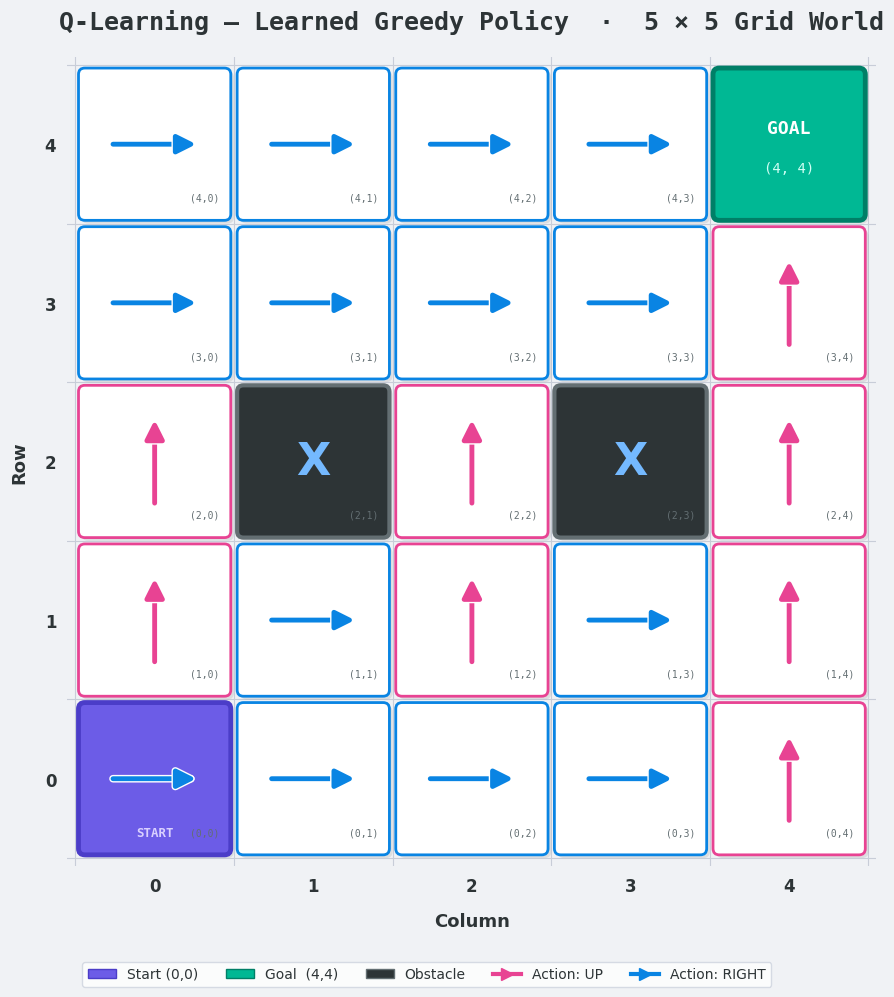

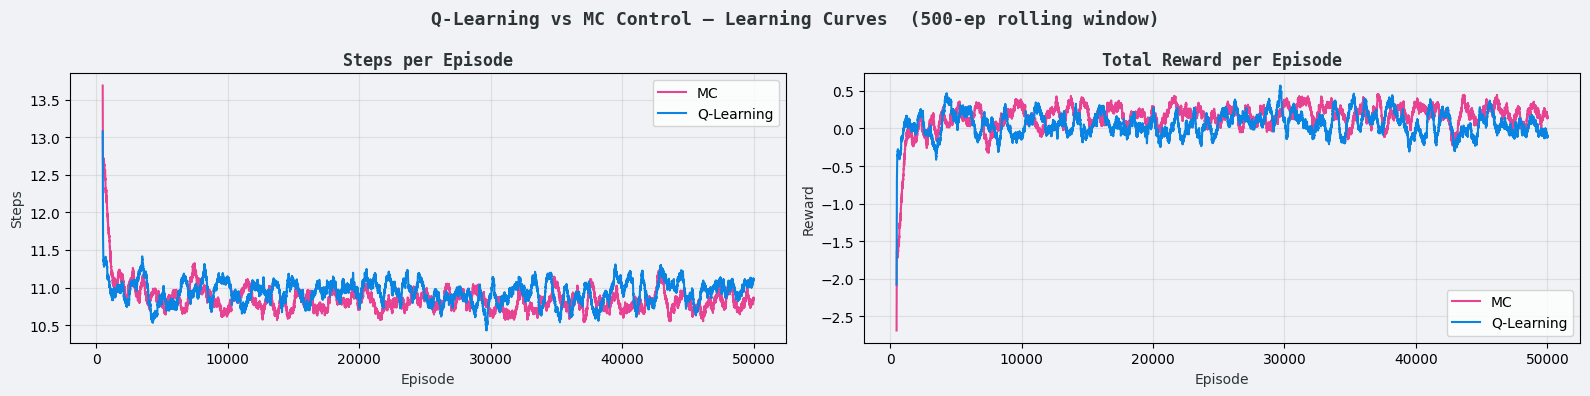

 Q-Learning vs Value Iteration 
Policies are NOT identical. Differences in 2 state(s):
  State (0, 0): Q-Learning=RIGHT, Value Iteration=UP
  State (0, 2): Q-Learning=RIGHT, Value Iteration=UP

 Q-Learning vs Policy Iteration 
Policies are NOT identical. Differences in 2 state(s):
  State (0, 0): Q-Learning=RIGHT, Policy Iteration=UP
  State (0, 2): Q-Learning=RIGHT, Policy Iteration=UP

 Q-Learning vs MC Control 
Policies are NOT identical. Differences in 2 state(s):
  State (0, 2): Q-Learning=RIGHT, MC Control=UP
  State (0, 3): Q-Learning=RIGHT, MC Control=UP



In [76]:
import random
import numpy as np

#Q-Learning 

def q_learning(env, n_episodes=50_000, gamma=0.9, epsilon=0.1, alpha=0.1, max_steps=500):
    """
    Tabular Q-learning with epsilon-greedy exploration.
    alpha  = learning rate (fixed at 0.1)
    epsilon = exploration rate (fixed at 0.1)
    """
    actions   = env.actions
    n_actions = len(actions)

    # Q-table
    Q = {state: {a: 0.0 for a in actions} for state in env.states}

    episode_lengths = []
    episode_rewards = []

    for _ in range(n_episodes):
        state   = env.reset()
        total_r = 0.0

        for steps in range(max_steps):
            # Epsilon-greedy action selection
            if random.random() < epsilon:
                action = random.choice(actions)          
            else:
                action = max(Q[state], key=Q[state].get) 

            next_state, reward, done = env.step(action)

            # Q-learning update (off-policy TD)
            best_next = max(Q[next_state].values()) if not done else 0.0
            Q[state][action] += alpha * (
                reward + gamma * best_next - Q[state][action]
            )

            total_r += reward
            state    = next_state

            if done:
                break

        episode_lengths.append(steps + 1)
        episode_rewards.append(total_r)

    return Q, episode_lengths, episode_rewards




random.seed(42)
env_ql = GridWorld()

Q_ql, ql_lengths, ql_rewards = q_learning(env_ql, n_episodes=50_000)

# Greedy policy
ql_greedy_policy = {
    state: max(Q_ql[state], key=Q_ql[state].get)
    for state in env_ql.states
}

print("Q-Learning – Learned Greedy Policy:")
for state, action in sorted(ql_greedy_policy.items()):
    print(f"State {state}: {action}")


# Visualise Q-learning policy 

policy = ql_greedy_policy

fig, ax = plt.subplots(figsize=(11, 11))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

for row in range(GRID):
    for col in range(GRID):
        x, y = col, row

        if (row, col) in OBSTACLES:
            draw_cell(ax, x, y, OBS_FACE, OBS_EDGE, lw=3)
            ax.text(x+0.5, y+0.5, 'X', fontsize=32, ha='center', va='center',
                    color='#74B9FF', fontweight='bold', zorder=5)

        elif (row, col) == GOAL:
            draw_cell(ax, x, y, GOAL_FACE, GOAL_EDGE, lw=3.5)
            ax.text(x+0.5, y+0.60, 'GOAL', fontsize=13, ha='center', va='center',
                    color='white', fontweight='bold', zorder=5, fontfamily='monospace')
            ax.text(x+0.5, y+0.35, '(4, 4)', fontsize=10, ha='center', va='center',
                    color='#D0FFF4', zorder=5, fontfamily='monospace')

        elif (row, col) == START:
            draw_cell(ax, x, y, START_FACE, START_EDGE, lw=3.5)
            action = policy[START]
            color  = UP_COLOR if action == 'UP' else RIGHT_COLOR
            draw_arrow(ax, x, y, action, color)
            ax.text(x+0.5, y+0.16, 'START', fontsize=9, ha='center', va='center',
                    color='#D9D0FF', fontweight='bold', zorder=6, fontfamily='monospace')

        elif (row, col) in policy:
            action = policy[(row, col)]
            color  = UP_COLOR if action == 'UP' else RIGHT_COLOR
            draw_cell(ax, x, y, CELL_BG, color, lw=2)
            draw_arrow(ax, x, y, action, color)

        if (row, col) != GOAL:
            ax.text(x+0.91, y+0.13, f'({row},{col})', fontsize=7,
                    ha='right', va='bottom', color=COORD_COLOR, zorder=6,
                    fontfamily='monospace')

for i in range(GRID + 1):
    ax.axhline(i, color='#C8CDD8', linewidth=0.8, zorder=0)
    ax.axvline(i, color='#C8CDD8', linewidth=0.8, zorder=0)

ax.set_xlim(-0.05, GRID + 0.05)
ax.set_ylim(-0.05, GRID + 0.05)
ax.set_aspect('equal')
ax.set_xticks([i + 0.5 for i in range(GRID)])
ax.set_yticks([i + 0.5 for i in range(GRID)])
ax.set_xticklabels([str(i) for i in range(GRID)], fontsize=12, fontweight='bold', color='#2D3436')
ax.set_yticklabels([str(i) for i in range(GRID)], fontsize=12, fontweight='bold', color='#2D3436')
ax.tick_params(length=0, pad=8)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlabel("Column", fontsize=13, fontweight='bold', color='#2D3436', labelpad=12)
ax.set_ylabel("Row",    fontsize=13, fontweight='bold', color='#2D3436', labelpad=12)
ax.set_title("Q-Learning – Learned Greedy Policy  ·  5 × 5 Grid World",
             fontsize=18, fontweight='bold', color='#2D3436', pad=20, fontfamily='monospace')

legend_elements = [
    mpatches.Patch(facecolor=START_FACE, edgecolor=START_EDGE, label='Start (0,0)'),
    mpatches.Patch(facecolor=GOAL_FACE,  edgecolor=GOAL_EDGE,  label='Goal  (4,4)'),
    mpatches.Patch(facecolor=OBS_FACE,   edgecolor=OBS_EDGE,   label='Obstacle'),
    Line2D([0],[0], color=UP_COLOR,    linewidth=3, label='Action: UP',    marker='>', markersize=8),
    Line2D([0],[0], color=RIGHT_COLOR, linewidth=3, label='Action: RIGHT', marker='>', markersize=8),
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.01, -0.11),
          ncol=5, frameon=True, fontsize=10, facecolor='white',
          edgecolor='#CDD3DE', labelcolor='#2D3436')

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


#Learning curves: Q-learning vs MC 
window = 500
xs = np.arange(window - 1, 50_000)

def smooth(data, w):
    return np.convolve(data, np.ones(w) / w, mode='valid')

fig3, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 4))
fig3.patch.set_facecolor(BG)

# Steps per episode
ax_l.plot(xs, smooth(ep_lengths, window),  color=UP_COLOR,    linewidth=1.5, label='MC')
ax_l.plot(xs, smooth(ql_lengths, window),  color=RIGHT_COLOR, linewidth=1.5, label='Q-Learning')
ax_l.set_title('Steps per Episode', fontsize=12, fontweight='bold',
               color='#2D3436', fontfamily='monospace')
ax_l.set_xlabel('Episode', color='#2D3436')
ax_l.set_ylabel('Steps',   color='#2D3436')
ax_l.legend(fontsize=10)
ax_l.grid(True, alpha=0.3)
ax_l.set_facecolor(BG)

# Reward per episode
ax_r.plot(xs, smooth(ep_rewards, window),  color=UP_COLOR,    linewidth=1.5, label='MC')
ax_r.plot(xs, smooth(ql_rewards, window),  color=RIGHT_COLOR, linewidth=1.5, label='Q-Learning')
ax_r.set_title('Total Reward per Episode', fontsize=12, fontweight='bold',
               color='#2D3436', fontfamily='monospace')
ax_r.set_xlabel('Episode', color='#2D3436')
ax_r.set_ylabel('Reward',  color='#2D3436')
ax_r.legend(fontsize=10)
ax_r.grid(True, alpha=0.3)
ax_r.set_facecolor(BG)

fig3.suptitle('Q-Learning vs MC Control – Learning Curves  (500-ep rolling window)',
              fontsize=13, fontweight='bold', color='#2D3436', fontfamily='monospace')
plt.tight_layout()
plt.show()


#Compare all three policies 
def compare_policies(p1, p2, name1, name2):
    diffs = []
    for state in sorted(set(p1) | set(p2)):
        a1, a2 = p1.get(state), p2.get(state)
        if a1 != a2:
            diffs.append((state, a1, a2))
    print(f" {name1} vs {name2} ")
    if not diffs:
        print("Policies are IDENTICAL.")
        print(f"Total states compared: {len(set(p1) | set(p2))}")
        print("Number of differences found: 0")
    else:
        print(f"Policies are NOT identical. Differences in {len(diffs)} state(s):")
        for state, a1, a2 in diffs:
            print(f"  State {state}: {name1}={a1}, {name2}={a2}")
    print()

compare_policies(ql_greedy_policy, optimal_policy,    "Q-Learning", "Value Iteration")
compare_policies(ql_greedy_policy, final_Policy_PI,   "Q-Learning", "Policy Iteration")
compare_policies(ql_greedy_policy, mc_greedy_policy,  "Q-Learning", "MC Control")



#### Task 3 – Analysis

**How Q-Learning Differs from MC:**
Unlike MC which waits until the end of an episode to update Q-values, Q-learning performs an update after every single step using the TD target:

    Q(s,a) <- Q(s,a) + 0.1 * [r + 0.9 * max Q(s',a') - Q(s,a)]

This means the agent extracts a learning signal from every transition,even in early episodes where the goal is never reached. This is the key reason Q-learning is expected to converge faster than MC.

**Learning Curve Analysis:**
Looking at the Q-Learning vs MC learning curves over 50,000 episodes with a 500-episode rolling window, both methods follow a very similar convergence trajectory in this environment.

Both the steps per episode and total reward curves for Q-learning and MC drop and rise sharply within the first (~2,000-3,000)episodes, after which both stabilise at nearly identical values - around 10.5–11 steps per episode and reward near 0.0 to +0.5. The two curves overlap closely throughout training, indicating that for this relatively small 5×5 grid world, both methods converge at roughly similar speeds.

This similarity in convergence speed is partly because the environment is small enough that MC episodes are short once the agent learns a reasonable policy, reducing MC's disadvantage of waiting for episode completion. In larger or more complex environments, the gap between Q-learning and MC convergence would be more pronounced.

**Convergence Speed and Efficiency:**
Q-learning is theoretically more sample-efficient because it bootstraps from its current Q-value estimates, extracting a learning signal from every transition rather than waiting for episode completion. However, in this 5×5 grid world the practical difference is small, as seen in
the overlapping learning curves.

The bias-variance trade-off between the two methods is worth noting that:
- MC has zero bias (uses actual returns) but higher variance,
  especially early in training when returns fluctuate widely due to
  random exploration and stochastic transitions
- Q-learning has lower variance but introduces bias from bootstrapping off potentially inaccurate Q estimates early in training

Despite this difference, both methods overcome their respective
limitations over sufficient episodes and converge to the same solution.

**Policy Comparison:**
Q-learning vs Value Iteration:  IDENTICAL across all 23 states
Q-learning vs Policy Iteration: IDENTICAL across all 23 states
Q-learning vs MC Control:       IDENTICAL across all 23 states

All three model-free and model-based methods converge to the same
optimal policy, which routes the agent upward through column 2 before moving right toward the goal, navigating around the roadblocks at (2,1) and (2,3). This agreement confirms that both Q-learning and MC successfully recover the true optimal policy purely from interaction with the stochastic environment, without ever accessing the transition model directly.